In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

100%|██████████| 292k/292k [00:00<00:00, 46.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [ ]:
import os

path = '/root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4'

os.listdir(path)

['car data.csv',
 'CAR DETAILS FROM CAR DEKHO.csv',
 'car details v4.csv',
 'Car details v3.csv']

In [ ]:
df = pd.read_csv(path + '/CAR DETAILS FROM CAR DEKHO.csv')

print(df.shape)
df.describe()

(4340, 8)


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


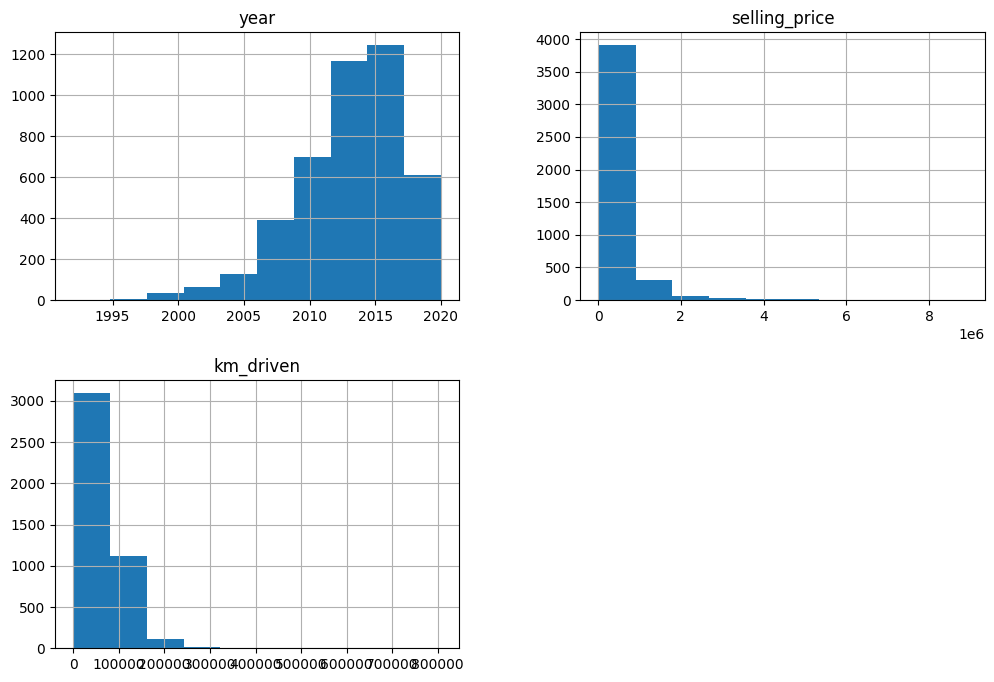

In [ ]:
df.hist(figsize=(12, 8))
plt.show()

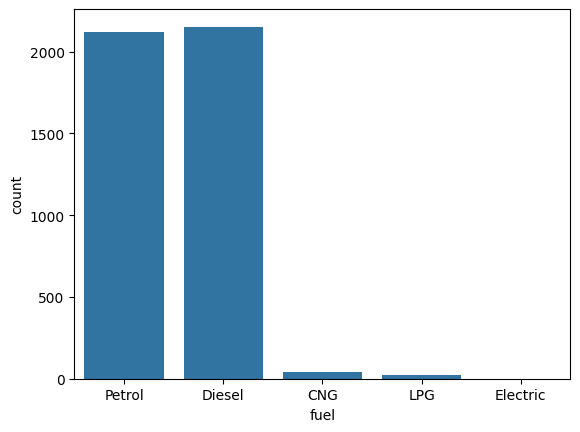

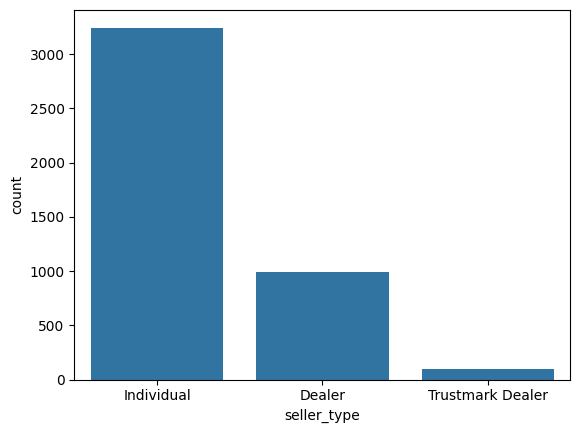

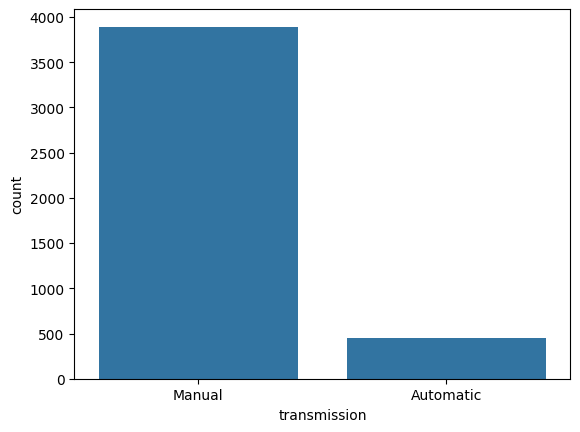

In [ ]:
sns.countplot(x='fuel', data=df)
plt.show()

sns.countplot(x='seller_type', data=df)
plt.show()

sns.countplot(x='transmission', data=df)
plt.show()

In [ ]:
X = df.drop(['selling_price', 'name'], axis=1)
y = df['selling_price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
ridge = Ridge()

params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(ridge, params, cv=5, scoring='r2')

ridge_grid.fit(X_train, y_train)

print(ridge_grid.best_params_)

{'alpha': 100}


In [ ]:
lasso = Lasso(max_iter=10000)

lasso_grid = GridSearchCV(lasso, params, cv=5, scoring='r2')

lasso_grid.fit(X_train, y_train)

print(lasso_grid.best_params_)

{'alpha': 100}


In [ ]:
ridge_pred = ridge_grid.predict(X_test)
lasso_pred = lasso_grid.predict(X_test)

In [ ]:
print("Ridge")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("R2:", r2_score(y_test, ridge_pred))

print("\nLasso")
print("MSE:", mean_squared_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("R2:", r2_score(y_test, lasso_pred))

Ridge
MSE: 151429682233.89862
RMSE: 389139.6693141148
MAE: 219041.42877775506
R2: 0.4998290573638059

Lasso
MSE: 150694953057.17654
RMSE: 388194.4783960438
MAE: 219920.92509697797
R2: 0.5022558615377444


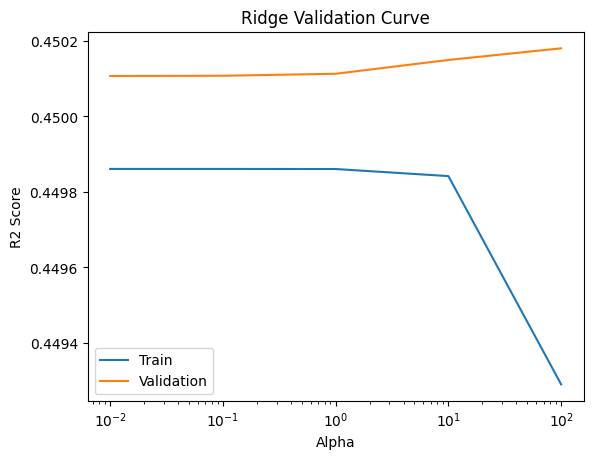

In [ ]:
from sklearn.model_selection import validation_curve

alphas = [0.01, 0.1, 1, 10, 100]

train_score, val_score = validation_curve(
    Ridge(),
    X_train,
    y_train,
    param_name='alpha',
    param_range=alphas,
    cv=5,
    scoring='r2'
)

plt.plot(alphas, train_score.mean(axis=1), label='Train')
plt.plot(alphas, val_score.mean(axis=1), label='Validation')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('Ridge Validation Curve')
plt.legend()
plt.show()

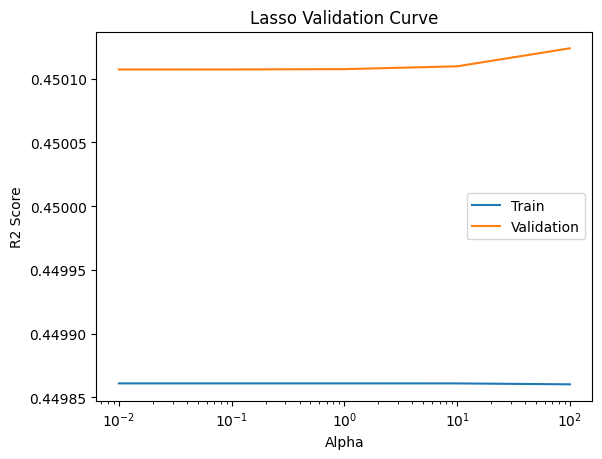

In [ ]:
train_score, val_score = validation_curve(
    Lasso(max_iter=10000),
    X_train,
    y_train,
    param_name='alpha',
    param_range=alphas,
    cv=5,
    scoring='r2'
)

plt.plot(alphas, train_score.mean(axis=1), label='Train')
plt.plot(alphas, val_score.mean(axis=1), label='Validation')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('Lasso Validation Curve')
plt.legend()
plt.show()

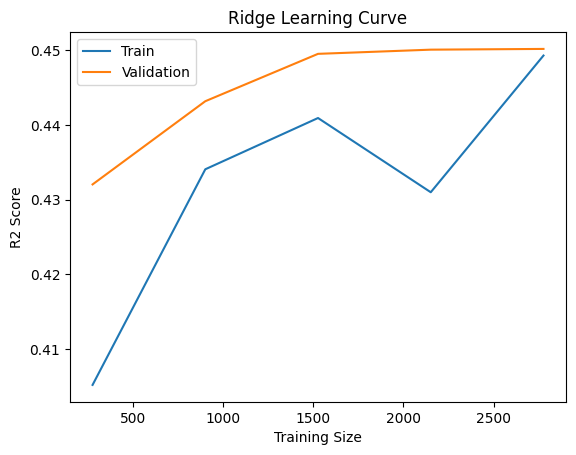

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=ridge_grid.best_params_['alpha']),
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R2 Score')
plt.title('Ridge Learning Curve')
plt.legend()
plt.show()

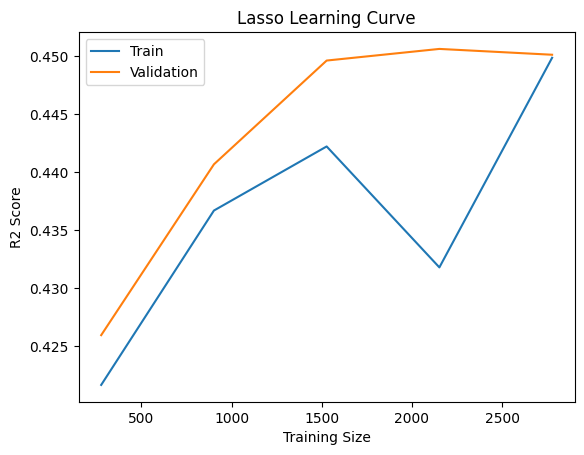

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000),
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R2 Score')
plt.title('Lasso Learning Curve')
plt.legend()
plt.show()

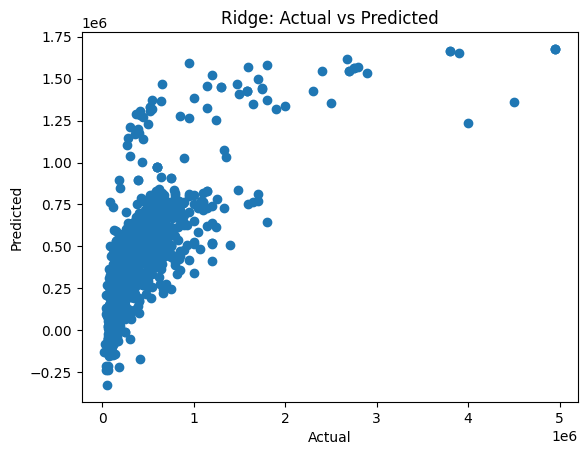

In [ ]:
plt.scatter(y_test, ridge_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Ridge: Actual vs Predicted')
plt.show()

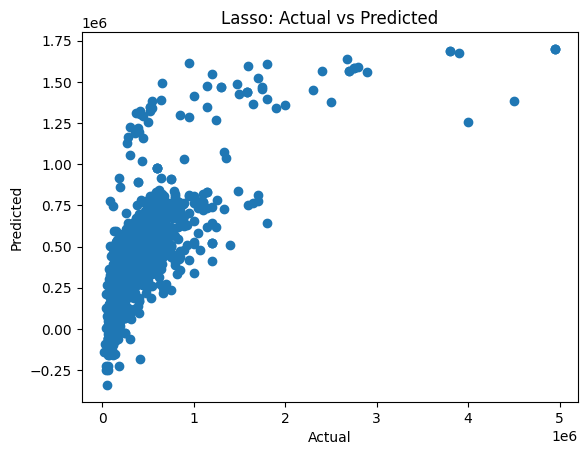

In [ ]:
plt.scatter(y_test, lasso_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Lasso: Actual vs Predicted')
plt.show()

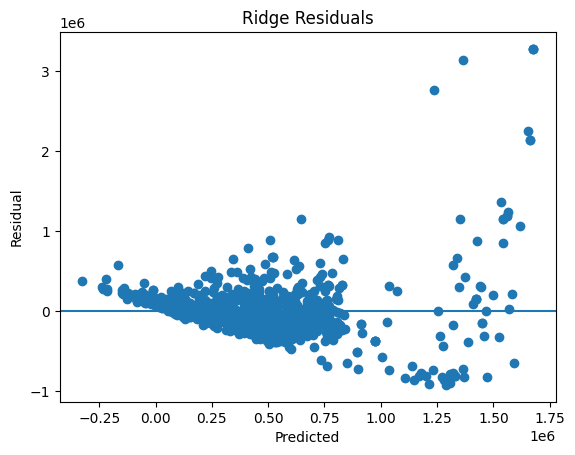

In [ ]:
plt.scatter(ridge_pred, y_test - ridge_pred)
plt.axhline(0)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Ridge Residuals')
plt.show()

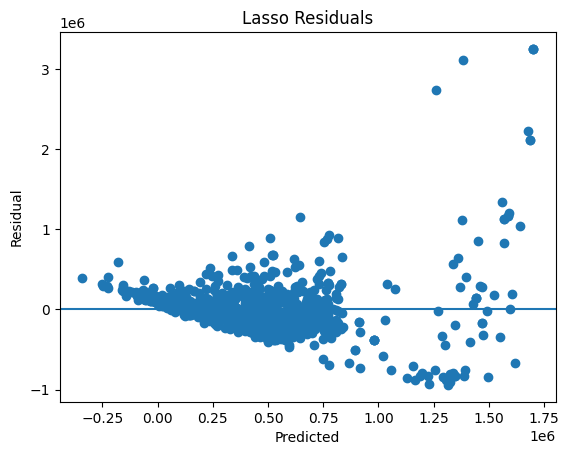

In [ ]:
plt.scatter(lasso_pred, y_test - lasso_pred)
plt.axhline(0)
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Lasso Residuals')
plt.show()

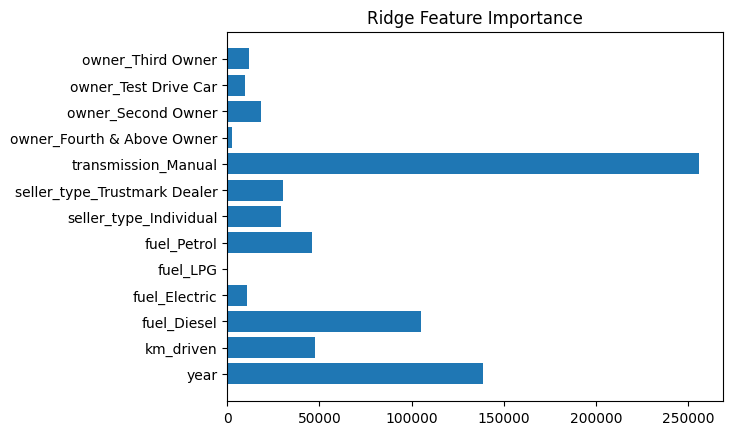

In [ ]:
plt.barh(X.columns, abs(ridge_grid.best_estimator_.coef_))
plt.title('Ridge Feature Importance')
plt.show()

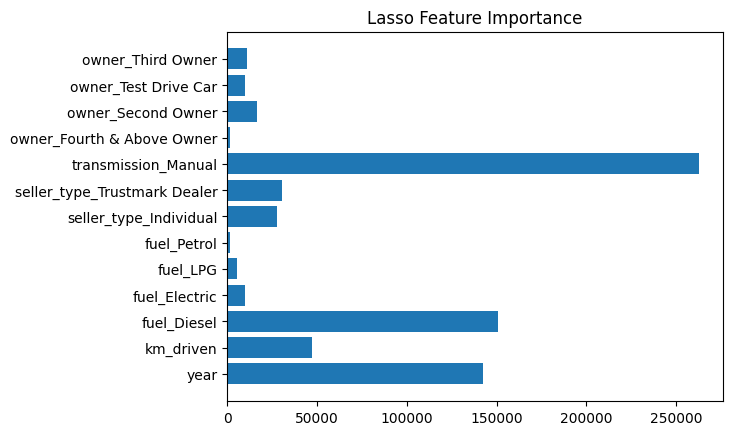

In [ ]:
plt.barh(X.columns, abs(lasso_grid.best_estimator_.coef_))
plt.title('Lasso Feature Importance')
plt.show()

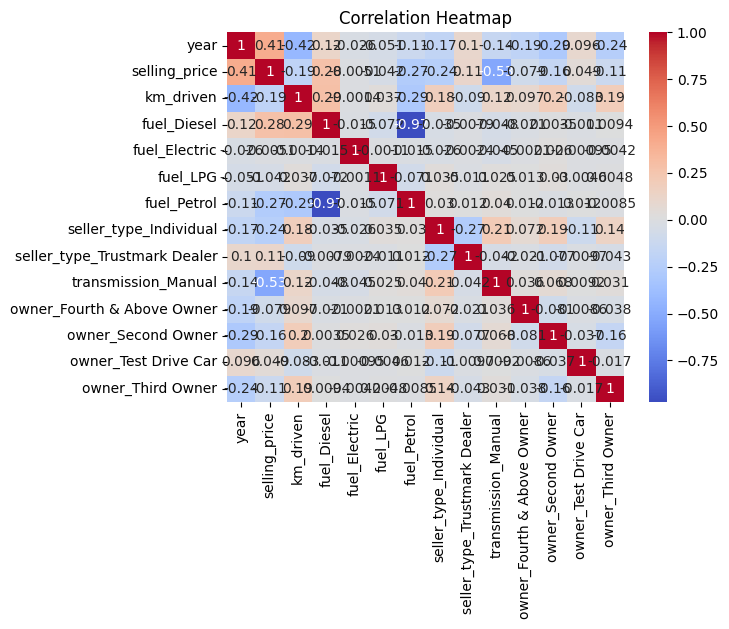

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
splits = [0.4, 0.3, 0.1]

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
    ridge.fit(X_train, y_train)

    pred = ridge.predict(X_test)

    print(f"{int((1-test_size)*100)}-{int(test_size*100)} Split")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE:", mean_absolute_error(y_test, pred))
    print("R2:", r2_score(y_test, pred))
    print()

60-40 Split
RMSE: 410540.171712846
MAE: 223968.3178709468
R2: 0.4548421814972735

70-30 Split
RMSE: 403431.16962885327
MAE: 218950.9756738399
R2: 0.4495155361380754

90-10 Split
RMSE: 342544.8045945307
MAE: 214513.72394796793
R2: 0.4281062429418364

